In [1]:
import os
MAIN_DIR='/home/jovyan/code4'
os.chdir(MAIN_DIR)
print(os.getcwd())

/home/jovyan/code4


In [2]:
import numpy as np
import pickle
import os
from pathlib import Path as Data_Path
import networkx as nx
from graph_building_routines import graph_attribute_builder
from spotify_data_loader import spotify_data_loader
from graph_analyzer import *

In [3]:
def dist_fitter(dist, edges, clip):
    indskp = dist > 0.
    yvals = np.log10(dist[indskp])
    xvals = np.log10(edges[:-1][indskp])
    indskp = xvals < clip
    coefficients = np.polyfit(xvals[indskp], yvals[indskp], 1)
    power = coefficients[0]
    cval = coefficients[1]
    return (power, cval, indskp)

In [4]:
Gred = pickle.load(open(f"{30}core_first_{30}.pkl", "rb"))


kcore_selected_playlists = [x for x,y in Gred.nodes(data=True) if y["node_type"]=="playlist"]
kcore_selected_tracks = [x for x,y in Gred.nodes(data=True) if y["node_type"]=="track"]
num_playlists = len(kcore_selected_playlists)
num_tracks = len(kcore_selected_tracks)
print(f"Number of kcore selected playlists: {num_playlists}")
print(f"Number of kcore selected tracks: {num_tracks}")

Number of kcore selected playlists: 12322
Number of kcore selected tracks: 7669


In [5]:
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams.update({ "text.usetex": True, "font.family": "serif" })
font = {'size': 16}
matplotlib.rc('font', **font)
fmt = 'pdf'

In [6]:
print(nx.is_bipartite(Gred))
print(Gred.number_of_nodes())
print(Gred.number_of_edges())

True
19991
832153


In [6]:
deg_seq = degree_sequence(Gred)

/home/jovyan/code4/graph_analyzer.py:17: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(etrim), np.log10(counts))


[3.1172041452863266, -2.8239035483296115]
[2.0563970690194244, -2.3172116750006255]


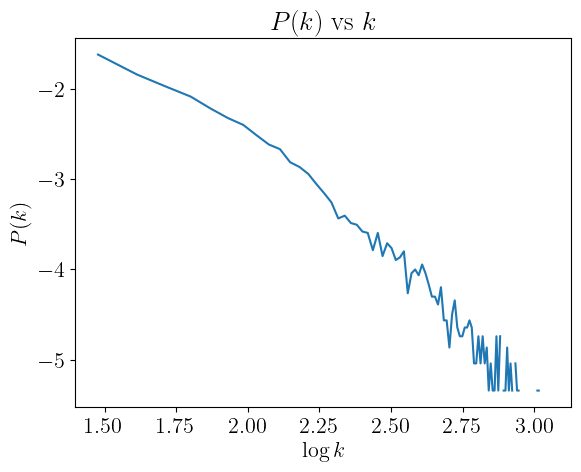

In [7]:
nbins = 100
dist, edges = plt_deg_distribution(deg_seq, nbins)
#plt.savefig("full_hist.pdf", dpi=150, bbox_inches='tight')  
etrim = edges[:-1]
powerfull, cvalfull, indskpfull = dist_fitter(dist, edges, 8.)
powertrunc, cvaltrunc, indskptrunc = dist_fitter(dist, edges, 2.5)
print([cvalfull, powerfull])
print([cvaltrunc, powertrunc])

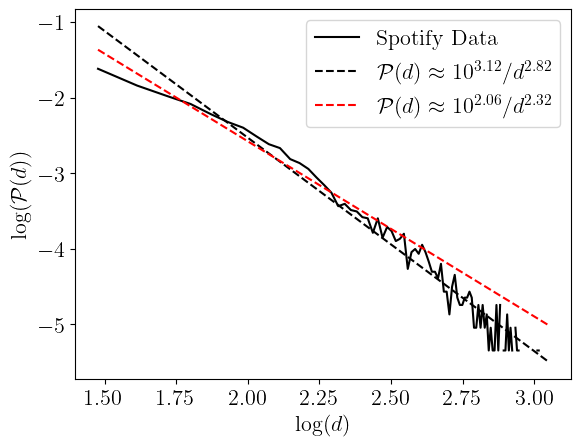

In [10]:
plt.plot(np.log10(etrim), np.ma.log10(dist),color='k', label ="Spotify Data")
scvalfull = "{:1.2f}".format(cvalfull)
spowerfull = "{:1.2f}".format(-powerfull)
scvaltrunc = "{:1.2f}".format(cvaltrunc)
spowertrunc = "{:1.2f}".format(-powertrunc)

plt.plot(np.log10(etrim), np.log10(10**(cvalfull) * (etrim)**powerfull), color='k', ls='--', label = r"$\mathcal{P}(d)\approx 10^{"+scvalfull+"}/d^{"+spowerfull+"}$")
plt.plot(np.log10(etrim), np.log10(10**(cvaltrunc) * (etrim)**powertrunc), color='r', ls='--', label = r"$\mathcal{P}(d)\approx 10^{"+scvaltrunc+"}/d^{"+spowertrunc+"}$")
plt.xlabel(r"$\log(d)$")
plt.ylabel(r"$\log(\mathcal{P}(d))$")
plt.legend()
plt.savefig("total_degree_dist_fit.pdf", dpi=150, bbox_inches='tight')  

In [11]:
from networkx.algorithms import bipartite

bmat = bipartite.biadjacency_matrix(Gred, row_order=kcore_selected_playlists, column_order=set(kcore_selected_tracks), dtype=np.float64)
d1 = np.sum(bmat, axis=1) #degrees of playlists
d2 = np.sum(bmat, axis=0) #degrees of tracks
degrees = np.concatenate((d1, d2))

/home/jovyan/code4/graph_analyzer.py:17: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(etrim), np.log10(counts))


[3.127023585934827, -2.854567416941737]
[1.512143839857251, -1.9765002210132743]


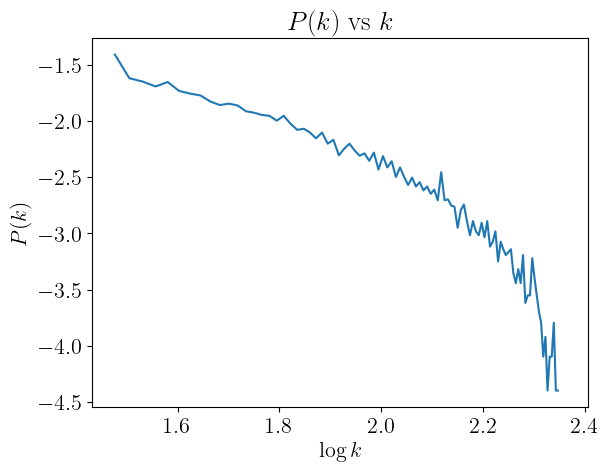

In [12]:
nbins = 100
dist, edges = plt_deg_distribution(d1, nbins)
#plt.savefig("p_hist.pdf", dpi=150, bbox_inches='tight')  
etrim = edges[:-1]
powerfull, cvalfull, indskpfull = dist_fitter(dist, edges, 8.)
powertrunc, cvaltrunc, indskptrunc = dist_fitter(dist, edges, 2.2)
print([cvalfull, powerfull])
print([cvaltrunc, powertrunc])

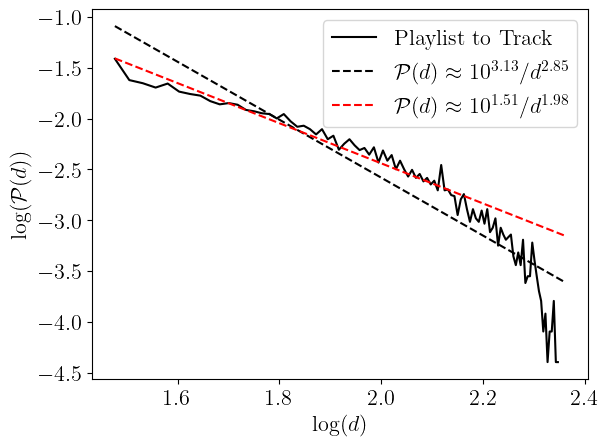

In [13]:
plt.plot(np.log10(etrim), np.ma.log10(dist),color='k', label="Playlist to Track")
scvalfull = "{:1.2f}".format(cvalfull)
spowerfull = "{:1.2f}".format(-powerfull)
scvaltrunc = "{:1.2f}".format(cvaltrunc)
spowertrunc = "{:1.2f}".format(-powertrunc)

plt.plot(np.log10(etrim), np.log10(10**(cvalfull) * (etrim)**powerfull), color='k', ls='--', label = r"$\mathcal{P}(d)\approx 10^{"+scvalfull+"}/d^{"+spowerfull+"}$")
plt.plot(np.log10(etrim), np.log10(10**(cvaltrunc) * (etrim)**powertrunc), color='r', ls='--', label = r"$\mathcal{P}(d)\approx 10^{"+scvaltrunc+"}/d^{"+spowertrunc+"}$")
plt.xlabel(r"$\log(d)$")
plt.ylabel(r"$\log(\mathcal{P}(d))$")
plt.legend()
plt.savefig("playlist_track_dist_fit.pdf", dpi=150, bbox_inches='tight')  

[2.433858610479717, -2.4280195467557855]
[0.8113542365887074, -1.6589799277209705]


/home/jovyan/code4/graph_analyzer.py:17: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(etrim), np.log10(counts))


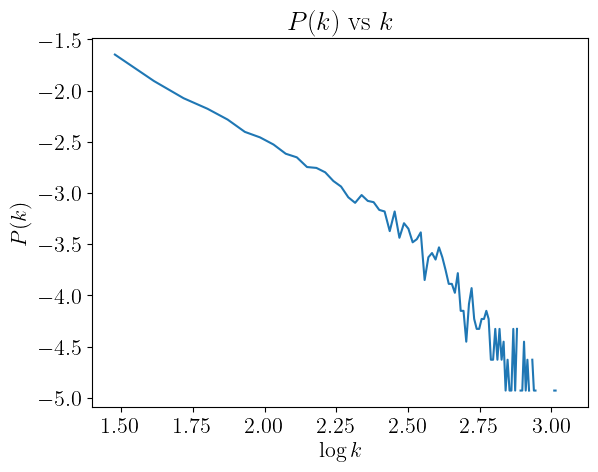

In [14]:
nbins = 100
dist, edges = plt_deg_distribution(d2, nbins)
#plt.savefig("p_hist.pdf", dpi=150, bbox_inches='tight')  
etrim = edges[:-1]
powerfull, cvalfull, indskpfull = dist_fitter(dist, edges, 8.)
powertrunc, cvaltrunc, indskptrunc = dist_fitter(dist, edges, 2.5)
print([cvalfull, powerfull])
print([cvaltrunc, powertrunc])

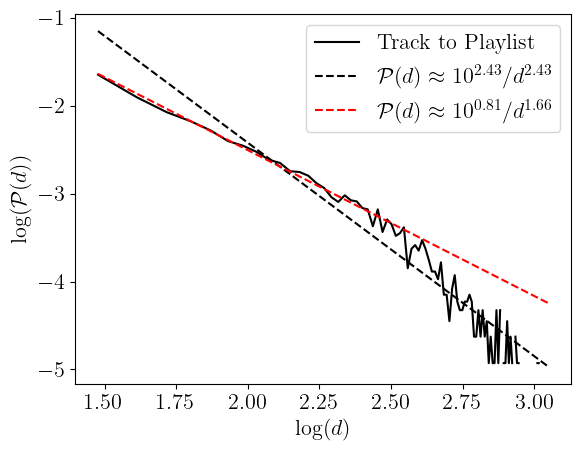

In [15]:
plt.plot(np.log10(etrim), np.ma.log10(dist),color='k', label="Track to Playlist")
scvalfull = "{:1.2f}".format(cvalfull)
spowerfull = "{:1.2f}".format(-powerfull)
scvaltrunc = "{:1.2f}".format(cvaltrunc)
spowertrunc = "{:1.2f}".format(-powertrunc)

plt.plot(np.log10(etrim), np.log10(10**(cvalfull) * (etrim)**powerfull), color='k', ls='--', label = r"$\mathcal{P}(d)\approx 10^{"+scvalfull+"}/d^{"+spowerfull+"}$")
plt.plot(np.log10(etrim), np.log10(10**(cvaltrunc) * (etrim)**powertrunc), color='r', ls='--', label = r"$\mathcal{P}(d)\approx 10^{"+scvaltrunc+"}/d^{"+spowertrunc+"}$")
plt.xlabel(r"$\log(d)$")
plt.ylabel(r"$\log(\mathcal{P}(d))$")
plt.legend()
plt.savefig("track_playlist_dist_fit.pdf", dpi=150, bbox_inches='tight')  